## What this notebook does

This notebook demonstrates how Fourier filtering changes an image by working in the **frequency domain**.

### Steps

1. **Load an example grayscale image** and convert it to floating point values in the range \([0,1]\).
2. **Compute the 2D Fourier transform** using the FFT, then apply `fftshift` so that the **zero frequency (DC)** is at the **center** of the spectrum.
3. **Visualize the spectrum amplitude** using a **log scale**:

   $$
   \log\bigl(1 + |F(u,v)|\bigr)
   $$

   The log is used because FFT magnitudes span a very large dynamic range; without log scaling, the center (low frequencies) would dominate and most details would look black.
4. **Create a circular frequency mask** using a radius \(r_0\) measured from the spectrum center:
   - **Low-pass mask:** keep frequencies inside the circle (smooth content).
   - **High-pass mask:** keep frequencies outside the circle (fine detail and edges).
5. **Apply the masks in the frequency domain** by multiplying:

   $$
   F_{\mathrm{LP}} = F \cdot \mathbf{1}\{r \le r_0\},
   \qquad
   F_{\mathrm{HP}} = F \cdot \mathbf{1}\{r \ge r_0\}
   $$
6. **Reconstruct filtered images** with the inverse FFT (`ifft2`) after undoing the shift (`ifftshift`), and take the real part:

   $$
   f_{\mathrm{LP}} = \Re\bigl(\mathrm{IFFT2}(\mathrm{ifftshift}(F_{\mathrm{LP}}))\bigr),
   \quad
   f_{\mathrm{HP}} = \Re\bigl(\mathrm{IFFT2}(\mathrm{ifftshift}(F_{\mathrm{HP}}))\bigr)
   $$
7. **Plot three spatial results**:
   - Original image
   - Low-pass filtered image (blurred / smoothed)
   - High-pass filtered image (edges + fine texture)

8. **Plot three frequency-domain views** (original / low-pass / high-pass) using a **grid of points** where point color represents the **log amplitude**. This makes it easy to see which parts of the spectrum are kept or removed.

### What to look for

- The **low-pass** result keeps only low frequencies, so it removes sharp edges and produces a **blurred** image.
- The **high-pass** result removes low frequencies, so it suppresses smooth shading and keeps **edges and fine texture**, often with noise-like appearance.
- The cutoff radius \(r_0\) controls the trade-off: smaller \(r_0\) means stronger filtering.


(512, 512) 0.0 1.0


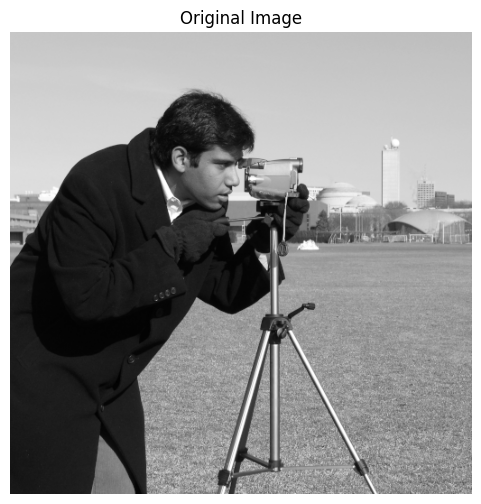

In [1]:
import numpy as np
import matplotlib.pyplot as plt


from skimage import data
from skimage.util import img_as_float

# Load an open sample image bundled with scikit-image (no download needed)
img = data.camera()                 # 512x512 grayscale
f = img_as_float(img)               # float in [0, 1]

print(f.shape, f.min(), f.max())
# Show the original image
plt.figure(figsize=(6, 6))
plt.imshow(f, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()


In [ ]:
# 2D FFT and shift DC to center
F = np.fft.fftshift(np.fft.fft2(f))

H, W = f.shape
cy, cx = H // 2, W // 2

Y, X = np.ogrid[:H, :W]
R = np.sqrt((Y - cy)**2 + (X - cx)**2)

In [14]:
# Show how the values of F are different the DC vs other frequencies, by taking random samples from the spectrum
print("\nRandom samples with log scaling:")
print(f"DC component (center): F[{cy}, {cx}] = {np.abs(F[cy, cx]):.2e}, log(1 + |F|) = {np.log1p(np.abs(F[cy, cx])):.2f}")
for _ in range(10):
    y = np.random.randint(0, H)
    x = np.random.randint(0, W)
    mag = np.abs(F[y, x])
    logmag = np.log1p(mag)
    print(f"F[{y}, {x}] = {mag:.2e}, log(1 + |F|) = {logmag:.2f}")



Random samples with log scaling:
DC component (center): F[256, 256] = 1.33e+05, log(1 + |F|) = 11.80
F[496, 307] = 1.36e+01, log(1 + |F|) = 2.68
F[216, 276] = 9.15e+01, log(1 + |F|) = 4.53
F[88, 317] = 1.04e+01, log(1 + |F|) = 2.43
F[297, 106] = 2.21e+01, log(1 + |F|) = 3.14
F[69, 319] = 2.50e+01, log(1 + |F|) = 3.26
F[138, 312] = 1.71e+01, log(1 + |F|) = 2.90
F[503, 352] = 9.71e+00, log(1 + |F|) = 2.37
F[281, 411] = 1.42e+01, log(1 + |F|) = 2.72
F[342, 133] = 2.60e+01, log(1 + |F|) = 3.30
F[99, 341] = 9.79e+00, log(1 + |F|) = 2.38


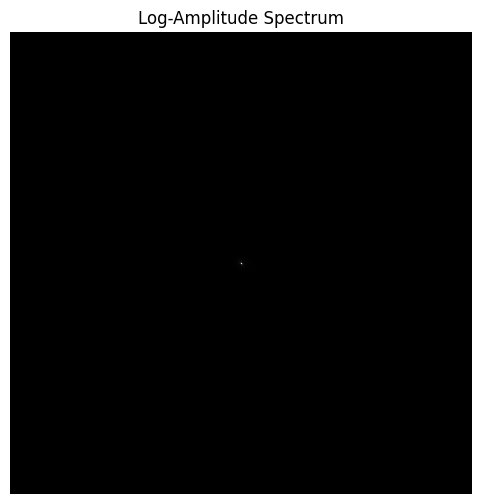

In [3]:
abs_amp = np.abs(F)
# Plot the log-amplitude spectrum
plt.figure(figsize=(6, 6))
plt.imshow(abs_amp, cmap='gray')
plt.title('Log-Amplitude Spectrum')
plt.axis('off')
plt.show()

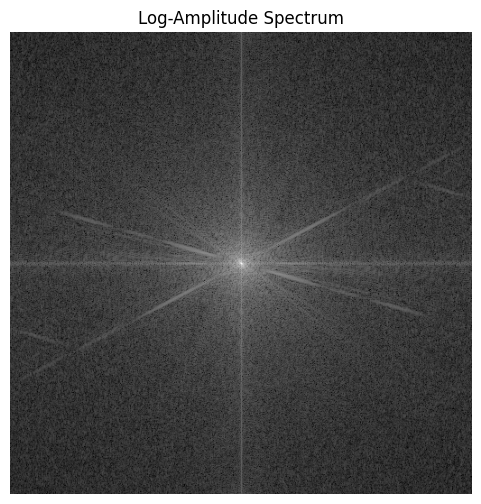

In [2]:


# Log-amplitude for visualization (more readable than raw magnitude)
logmag = np.log1p(np.abs(F))
# Plot the log-amplitude spectrum
plt.figure(figsize=(6, 6))
plt.imshow(logmag, cmap='gray')
plt.title('Log-Amplitude Spectrum')
plt.axis('off')
plt.show()

In [4]:
# Adjust this cutoff radius (in frequency-index pixels)
r0 = 60

mask_lp = (R <= r0).astype(float)
mask_hp = (R >= r0).astype(float)

def reconstruct(F_shifted_masked):
    # Undo shift, inverse FFT, take real part
    rec = np.fft.ifft2(np.fft.ifftshift(F_shifted_masked))
    return np.real(rec)

F_lp = F * mask_lp
F_hp = F * mask_hp

f_lp = np.clip(reconstruct(F_lp), 0, 1)
f_hp = np.clip(reconstruct(F_hp), 0, 1)


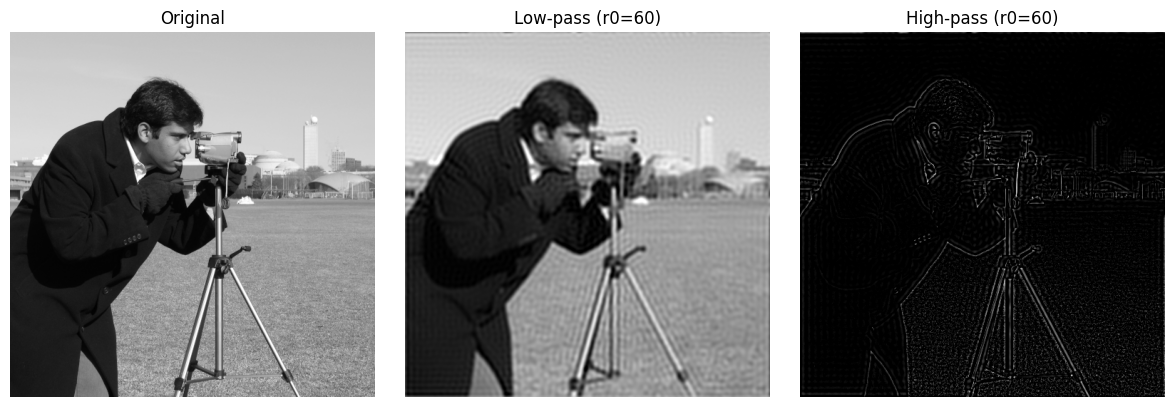

In [5]:

fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(f, cmap="gray")
ax1.set_title("Original")
ax1.axis("off")

ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(f_lp, cmap="gray")
ax2.set_title(f"Low-pass (r0={r0})")
ax2.axis("off")

ax3 = fig.add_subplot(1, 3, 3)
ax3.imshow(f_hp, cmap="gray")
ax3.set_title(f"High-pass (r0={r0})")
ax3.axis("off")

plt.tight_layout()
plt.show()


In [7]:
from IPython import get_ipython
from IPython.display import display, clear_output
import ipywidgets as widgets

# Pick the best available backend for interactive updates
ip = get_ipython()
use_widget_backend = False
if ip is not None:
    try:
        ip.run_line_magic("matplotlib", "widget")
        use_widget_backend = True
    except RuntimeError:
        try:
            ip.run_line_magic("matplotlib", "notebook")
        except RuntimeError:
            ip.run_line_magic("matplotlib", "inline")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# Hide toolbar icons for ipympl widget figures
if hasattr(fig.canvas, "toolbar_visible"):
    fig.canvas.toolbar_visible = False

im_orig = axes[0].imshow(f, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")
im_lp = axes[1].imshow(f_lp, cmap="gray")
axes[1].set_title(f"Low-pass r0={r0}")
axes[1].axis("off")
im_hp = axes[2].imshow(f_hp, cmap="gray")
axes[2].set_title(f"High-pass r0={r0}")
axes[2].axis("off")
plt.tight_layout()

slider = widgets.IntSlider(min=5, max=min(H, W) // 2, step=5, value=r0, description="r0")
out = widgets.Output()
with out:
    display(fig)


def update(r0):
    mask_lp = (R <= r0).astype(float)
    mask_hp = (R >= r0).astype(float)
    f_lp = np.clip(reconstruct(F * mask_lp), 0, 1)
    f_hp = np.clip(reconstruct(F * mask_hp), 0, 1)
    im_lp.set_data(f_lp)
    axes[1].set_title(f"Low-pass r0={r0}")
    im_hp.set_data(f_hp)
    axes[2].set_title(f"High-pass r0={r0}")
    if use_widget_backend:
        fig.canvas.draw_idle()
    else:
        with out:
            clear_output(wait=True)
            display(fig)


def _on_slider_change(change):
    if change["name"] == "value":
        update(change["new"])


slider.observe(_on_slider_change, names="value")
display(widgets.VBox([slider, out]))


<IPython.core.display.Javascript object>